# DX702 Quiz 5

## Imports

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
import warnings

from sklearn.linear_model import LinearRegression

random_state    = 42
testsize        = 0.2


## Methods and Madness

In [27]:

def run_simulation(num_experiments      = 1000, 
                   num_samples          = 100, 
                   random_state         = 42, 
                   accident_likelihood  = False
                   ):
    print("Accident likelihood included.") if accident_likelihood else None

    np.random.seed(random_state)
    noise           = np.random.normal(0, 0.3, num_samples)
    coefficients    = []

    for _ in range(num_experiments):
        difficulty  = np.random.uniform(0, 1, num_samples)
        speed       = np.maximum(np.random.normal(15, 5, num_samples) - difficulty * 10, 0)
        accident    = np.minimum(np.maximum(0.03 * speed + 0.4 * difficulty + noise, 
                                            0),
                                1) 
        if accident_likelihood:
            df  = pd.DataFrame({'difficulty': difficulty, 'speed': speed , 'accident': accident})
            X   = df[['difficulty', 'accident']]
        else:
            df  = pd.DataFrame({'difficulty': difficulty, 'speed': speed})
            X   = df[['difficulty']]

        Y   = df['speed']
        
        model = LinearRegression()
        model.fit(X, Y)
        
        # Store coefficient
        coefficients.append(model.coef_[0])

    return coefficients


In [28]:
def plot_coefficient_distribution(coefficients):
    plt.figure(figsize=(6, 4))
    sns.histplot(coefficients, kde=True, stat="density", bins=30, color='midnightblue')
    plt.title('Distribution of Coefficients in Predicting Speed')
    plt.xlabel('Coefficient Value', fontsize=10)
    plt.ylabel('Density')
    plt.axvline(np.mean(coefficients), color='red', linestyle='--', label=f'Mean = {np.mean(coefficients):.4f}')
    plt.legend()
    plt.tight_layout()
    plt.show()

In this example, <br>
- `Z = the likelihood of a biking accident`, 
- `Y = speed`
- `X = trail difficulty`. 

We assume that X &darr; Y causally because people decrease their speed on difficult trails. In addition, Y and X both &uarr; ﻿Z﻿ causally because fast biking on difficult trails leads to accidents. 

Difficulty will be on a scale from 0 to 1, speed in miles per hour, and likelihood of an accident also on a scale from 0 to 1. 

(Based on the numbers, I'd say these trails are quite challenging!) 

In [29]:
#df.head(n=10)

In [30]:
#df.describe()

## Question 1

Use ﻿X﻿ to predict ﻿Y﻿ many times via regression with different data sets. Use many samples in each prediction. 

Which is closest to the average coefficient of ﻿X﻿ if you do the experiment enough times? 


Option A
-9.243

<font color = 'cyan'>

**Option B
-9.661**

</font>
Option C
-8.927

Option D
-10.14



In [31]:
experiment_count = 5000 # Number of experiments to run
num              = 100 # Number of samples per experiment

coeffs_X         = run_simulation(num_experiments = experiment_count, num_samples = num, random_state = random_state, accident_likelihood = False)


print(f"Average coefficient of difficulty (X) in predicting speed (Y): {np.mean(coeffs_X):.4f}")
#

Average coefficient of difficulty (X) in predicting speed (Y): -9.6615


Negative value aligns with assumption that higher trail difficulty leads to lower biking speed

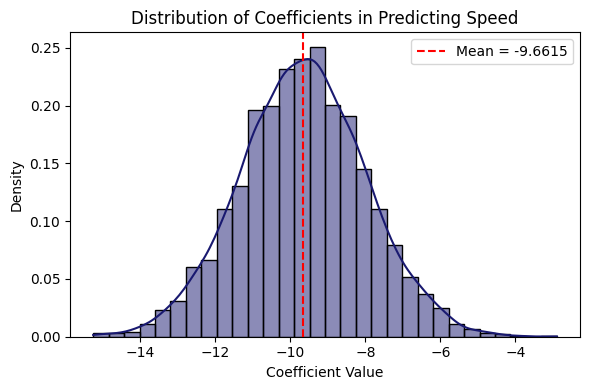

In [32]:
plot_coefficient_distribution(coeffs_X)

## Question 2

Then use ﻿X﻿ and ﻿Z﻿ to predict ﻿Y﻿ many times via regression with different datasets. Which of these is closest to the average coefficient of ﻿X﻿? 

Option A
-9.821

<font color = 'cyan'>

**Option B
-10.33**

</font>

Option C
-10.85

Option D
-11.23




In [33]:
coeffs_X         = run_simulation(num_experiments       = 100000,
                                   num_samples          = num, 
                                   random_state         = random_state, 
                                   accident_likelihood  = True)


print(f"Average coefficient of difficulty (X) and accident likelihood in predicting speed (Y): {np.mean(coeffs_X):.4f}")

Accident likelihood included.
Average coefficient of difficulty (X) and accident likelihood in predicting speed (Y): -10.4309


Purpose of the regression was to predict speed using both difficulty and accident (speed ~ difficulty + accident).

This setup introduces a statistical phenomenon known as collider bias.

Causal Structure: In this problem, both difficulty and speed are causes of accident. When two variables (difficulty, speed) independently cause a third variable (accident), that third variable is called a "collider."

Code snippet

graph TD
    D(Difficulty) --> S(Speed)
    D --> A(Accident)
    S --> A
Collider Bias: In a regression, if you control for a collider (i.e., include accident as a predictor in the model speed ~ difficulty + accident), you create a spurious statistical association between its causes.

The Effect: The original relationship between difficulty and speed is approximately -10. When you add accident to the regression, the model tries to account for it. For a given accident rate, if the difficulty was high, the model will infer that the speed must have been even lower than usual. This "explaining away" effect makes the negative relationship between difficulty and speed appear stronger than it actually is. Therefore, the coefficient for difficulty will become more negative than -10.
